In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Task 1 — A Single Neuron in NumPy

You'll start with one neuron — a logistic regression in disguise.

1. Load the Breast Cancer dataset, split into train/test (`test_size=0.2`, `random_state=42`), and scale the features with `StandardScaler`.
2. Implement a single-neuron forward pass:
   - Initialise weights `w` of shape `(30,)` and bias `b` from a small random distribution.
   - Implement `forward(x, w, b)` that returns `sigmoid(w·x + b)`.
   - Run it on the first 5 test rows. Report the predicted probabilities.
3. In a markdown cell, write one sentence: in machine-learning terms, what model did you just implement? 

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

np.random.seed(42)

w = np.random.randn(30) * 0.01   
b = np.random.randn() * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    return sigmoid(np.dot(w, x) + b)

predictions = []

for i in range(5):
    prob = forward(X_test[i], w, b)
    predictions.append(prob)

print("Predicted probabilities:")
print(predictions) 

Predicted probabilities:
[np.float64(0.4962245695737439), np.float64(0.5175402839909198), np.float64(0.5070800493970136), np.float64(0.4874400158003255), np.float64(0.4839460770261141)]


This is a single-neuron neural network, which is mathematically equivalent to logistic regression.

### Task 2 — A Two-Layer MLP in NumPy

Now stack neurons into a real network.

1. Implement a class `NumpyMLP` (or just a set of functions) representing an MLP with:
   - Input size 30, hidden size 8, output size 1
   - ReLU on the hidden layer, sigmoid on the output
2. Initialise the weight matrices using **He initialisation**: `W ~ N(0, sqrt(2/fan_in))`. Initialise biases to zero.
3. Implement a `forward(X)` that takes a batch `(N, 30)` and returns predictions `(N, 1)`. Use vectorised NumPy — no Python loops over rows.
4. Run a forward pass on the test set. Print the shape of the output and the first 5 predictions.

**Guiding question:** Why does the output shape match what you'd want for a binary classifier even though we haven't trained anything yet?

In [2]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()

X = data.data
y = data.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):

        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size) 
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size) 
        self.b2 = np.zeros((1, output_size)) 

    def forward(self, X): 

        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1) 

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2


np.random.seed(42) 

model = NumpyMLP() 

predictions = model.forward(X_test) 

print("Output shape:", predictions.shape) 

print("\nFirst 5 predictions:") 
print(predictions[:5]) 

Output shape: (114, 1)

First 5 predictions:
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]


The output shape is (N, 1) because the network produces one probability for each sample — exactly what a binary classifier needs. The sigmoid output keeps values between 0 and 1, so each output can be interpreted as the probability of belonging to the positive class.

### Task 3 — The Same Network in PyTorch

Recreate Task 2 using PyTorch's high-level API.

1. Define a class `TorchMLP(nn.Module)` with the same architecture (30 → 8 → 1, ReLU then Sigmoid).
2. Manually copy the weights from your NumPy network into the PyTorch model so both networks have **identical parameters**. Hint: `model.fc1.weight.data = torch.from_numpy(W1).float()` and similar for biases. Be careful with shapes — `nn.Linear` stores weights as `(out, in)`.
3. Run the same test batch through the PyTorch model. Compare the outputs to the NumPy outputs. They should match to at least 6 decimal places.
4. Report the maximum absolute difference between the two outputs.

**Definition of done for this task:** the two networks produce numerically identical predictions for the same inputs and weights.

In [3]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


data = load_breast_cancer()

X = data.data
y = data.target.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):

        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):

        z1 = X @ self.W1 + self.b1
        a1 = relu(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = sigmoid(z2)

        return a2


np.random.seed(42)

numpy_model = NumpyMLP()

numpy_outputs = numpy_model.forward(X_test)


class TorchMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.sigmoid(x)

        return x

torch_model = TorchMLP()


# IMPORTANT:
# PyTorch Linear weights are stored as (out_features, in_features)
# NumPy weights are stored as (in_features, out_features)
# So we transpose them.

torch_model.fc1.weight.data = torch.from_numpy(
    numpy_model.W1.T
).float()

torch_model.fc1.bias.data = torch.from_numpy(
    numpy_model.b1.flatten()
).float()

torch_model.fc2.weight.data = torch.from_numpy(
    numpy_model.W2.T
).float()

torch_model.fc2.bias.data = torch.from_numpy(
    numpy_model.b2.flatten()
).float()


X_test_tensor = torch.from_numpy(X_test).float()

with torch.no_grad():
    torch_outputs = torch_model(X_test_tensor).numpy()


max_difference = np.max(np.abs(numpy_outputs - torch_outputs))

print("NumPy first 5 predictions:")
print(numpy_outputs[:5])

print("\nPyTorch first 5 predictions:")
print(torch_outputs[:5])

print("\nMaximum absolute difference:")
print(max_difference) 

NumPy first 5 predictions:
[[0.45299955]
 [0.46601069]
 [0.56604814]
 [0.40817775]
 [0.36364703]]

PyTorch first 5 predictions:
[[0.45299956]
 [0.46601075]
 [0.56604815]
 [0.40817776]
 [0.363647  ]]

Maximum absolute difference:
6.854759015961776e-08


### Task 4 — Activation Function Experiment

Time to experiment.

1. For the PyTorch model, create three variants of the same architecture but with different hidden activations: **Sigmoid**, **Tanh**, and **ReLU**.
2. For each variant, run a forward pass on the **same** scaled test set.
3. Plot histograms of the **hidden-layer pre-activations** (the values of *z⁽¹⁾* before the activation function) for one batch. Use a 1×3 subplot.
4. Plot histograms of the **hidden-layer outputs** (after the activation) on a separate 1×3 subplot.
5. In a markdown cell, answer:
   - For Sigmoid and Tanh, what fraction of the post-activation values fall in the saturated region (close to 0/1 for sigmoid, close to ±1 for tanh)?
   - Looking at ReLU: roughly what fraction of the units are inactive (output exactly 0)?
   - Based on these histograms, why might ReLU be the better default for hidden layers?

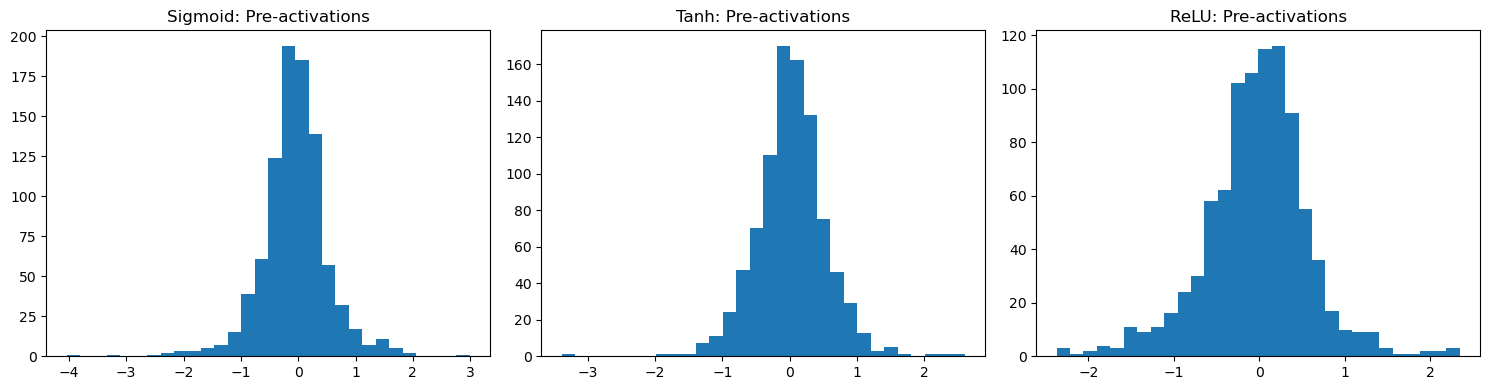

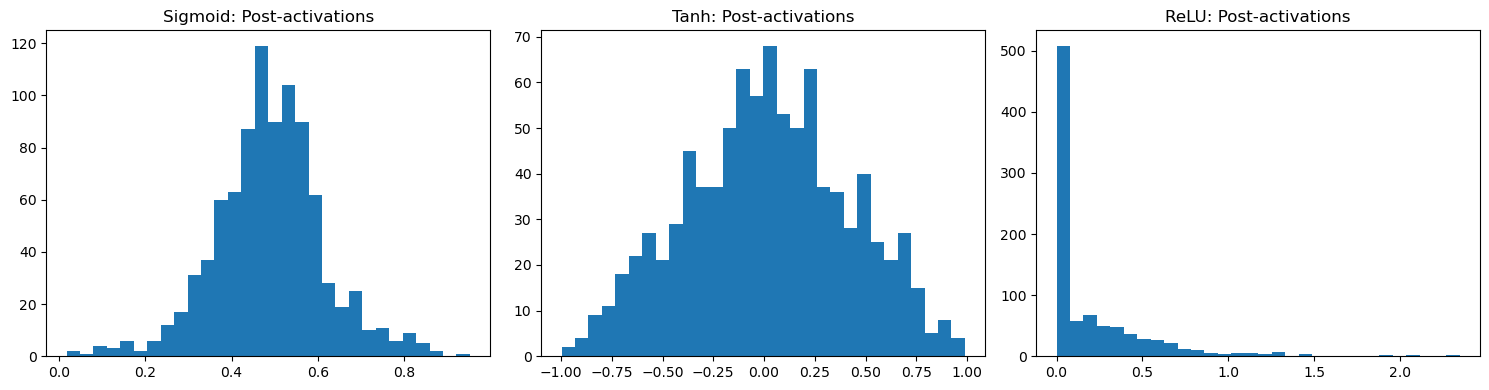

Sigmoid saturated fraction: 0.003289473684210526
Tanh saturated fraction: 0.005482456140350877
ReLU inactive fraction: 0.49780701754385964


In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================
# Load and prepare data
# =====================================================
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# =====================================================
# Model definition
# =====================================================
class ActivationMLP(nn.Module):

    def __init__(self, activation_name="relu"):
        super().__init__()

        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)

        if activation_name == "sigmoid":
            self.activation = nn.Sigmoid()

        elif activation_name == "tanh":
            self.activation = nn.Tanh()

        elif activation_name == "relu":
            self.activation = nn.ReLU()

        self.output_activation = nn.Sigmoid()

    def forward(self, x):

        # Pre-activation values
        z1 = self.fc1(x)

        # Hidden activations
        a1 = self.activation(z1)

        # Output layer
        z2 = self.fc2(a1)

        out = self.output_activation(z2)

        return out, z1, a1

# =====================================================
# Create models
# =====================================================
torch.manual_seed(42)

sigmoid_model = ActivationMLP("sigmoid")
tanh_model = ActivationMLP("tanh")
relu_model = ActivationMLP("relu")

# =====================================================
# Forward passes
# =====================================================
with torch.no_grad():

    _, z_sigmoid, a_sigmoid = sigmoid_model(X_test_tensor)

    _, z_tanh, a_tanh = tanh_model(X_test_tensor)

    _, z_relu, a_relu = relu_model(X_test_tensor)

# Convert to NumPy
z_sigmoid = z_sigmoid.numpy().flatten()
z_tanh = z_tanh.numpy().flatten()
z_relu = z_relu.numpy().flatten()

a_sigmoid = a_sigmoid.numpy().flatten()
a_tanh = a_tanh.numpy().flatten()
a_relu = a_relu.numpy().flatten()

# =====================================================
# Plot pre-activations
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(z_sigmoid, bins=30)
axes[0].set_title("Sigmoid: Pre-activations")

axes[1].hist(z_tanh, bins=30)
axes[1].set_title("Tanh: Pre-activations")

axes[2].hist(z_relu, bins=30)
axes[2].set_title("ReLU: Pre-activations")

plt.tight_layout()
plt.show()

# =====================================================
# Plot post-activations
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(a_sigmoid, bins=30)
axes[0].set_title("Sigmoid: Post-activations")

axes[1].hist(a_tanh, bins=30)
axes[1].set_title("Tanh: Post-activations")

axes[2].hist(a_relu, bins=30)
axes[2].set_title("ReLU: Post-activations")

plt.tight_layout()
plt.show()

# =====================================================
# Saturation / inactivity statistics
# =====================================================

# Sigmoid saturation:
# close to 0 or 1
sigmoid_saturated = np.mean(
    (a_sigmoid < 0.05) | (a_sigmoid > 0.95)
)

# Tanh saturation:
# close to -1 or +1
tanh_saturated = np.mean(
    np.abs(a_tanh) > 0.95
)

# ReLU inactive:
# exactly 0
relu_inactive = np.mean(a_relu == 0)

print("Sigmoid saturated fraction:", sigmoid_saturated)

print("Tanh saturated fraction:", tanh_saturated)

print("ReLU inactive fraction:", relu_inactive) 

- Sigmoid pushes many outputs toward 0 or 1. In those saturated regions, gradients become extremely small, so learning slows down.
- Tanh has the same saturation problem near -1 and +1, although it is usually a bit better because its outputs are centered around zero.
- ReLU sets negative values to exactly 0, so some neurons become inactive, but positive values remain unsaturated and can keep strong gradients.

ReLU is often the better default for hidden layers because:
1. it avoids strong saturation for positive activations,
2. gradients stay larger and more stable,
3. training is usually faster,
4. and sparse activations (many zeros) can improve efficiency. 